In [3]:
import pandas as pd
data = pd.read_csv(r"C:\Users\KALAIVANI\Downloads\Loan prediction.csv")
print("Missing values:\n", data.isnull().sum())
data.to_csv("loan_cleaned.csv", index=False)
print("Data cleaning completed. Saved as loan_cleaned.csv")


Missing values:
 Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64
Data cleaning completed. Saved as loan_cleaned.csv


In [33]:
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History Property_Area  
0             1.0         Urban  
1             1.0         Urban  
2             1.0         Urban  
3             NaN     

In [34]:
print("Rows and Columns:", df.shape)

Rows and Columns: (367, 12)


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [36]:
print(df.tail())

      Loan_ID Gender Married Dependents     Education Self_Employed  \
362  LP002971   Male     Yes         3+  Not Graduate           Yes   
363  LP002975   Male     Yes          0      Graduate            No   
364  LP002980   Male      No          0      Graduate            No   
365  LP002986   Male     Yes          0      Graduate            No   
366  LP002989   Male      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
362             4009               1777       113.0             360.0   
363             4158                709       115.0             360.0   
364             3250               1993       126.0             360.0   
365             5000               2393       158.0             360.0   
366             9200                  0        98.0             180.0   

     Credit_History Property_Area  
362             1.0         Urban  
363             1.0         Urban  
364             NaN     Se

In [37]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Loan_ID : 367
Gender : 2
Married : 2
Dependents : 4
Education : 2
Self_Employed : 2
ApplicantIncome : 314
CoapplicantIncome : 194
LoanAmount : 144
Loan_Amount_Term : 12
Credit_History : 2
Property_Area : 3


In [38]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
data = pd.read_csv(r"C:\Users\KALAIVANI\Downloads\Loan prediction.csv")

le = LabelEncoder()
for col in data.select_dtypes(include=["object"]).columns:
    data[col] = le.fit_transform(data[col])

data.to_csv("loan_prepared.csv", index=False)
print("Data preparation completed. Saved as loan_prepared.csv")


Data preparation completed. Saved as loan_prepared.csv


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
data = pd.read_csv(r"C:\Users\KALAIVANI\Downloads\Loan prediction.csv")

data["Loan_Amount_Term"] = pd.to_numeric(data["Loan_Amount_Term"], errors="coerce")

data = data.dropna(subset=["Loan_Amount_Term"])

X = data.drop("Loan_Amount_Term", axis=1)
y = data["Loan_Amount_Term"]

X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 2961.753807680994
R2 Score: -0.04435882438277616


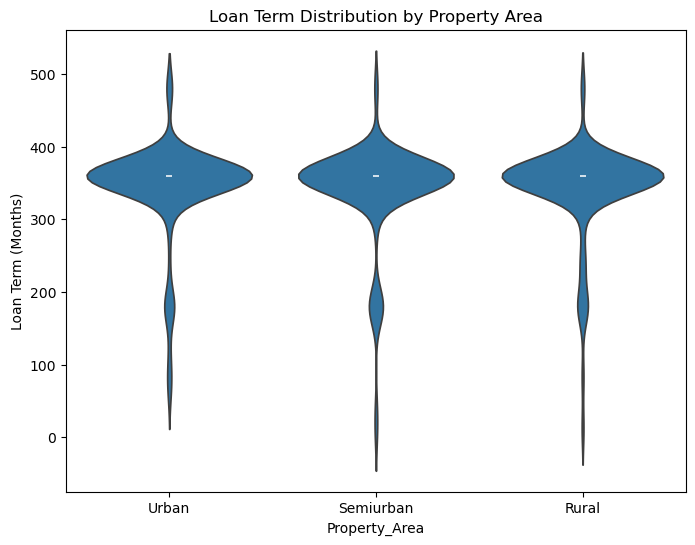

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv(r"C:\Users\KALAIVANI\Downloads\Loan prediction.csv")

plt.figure(figsize=(8,6))
sns.violinplot(x="Property_Area", y="Loan_Amount_Term", data=data)
plt.title("Loan Term Distribution by Property Area")
plt.ylabel("Loan Term (Months)")
plt.show()


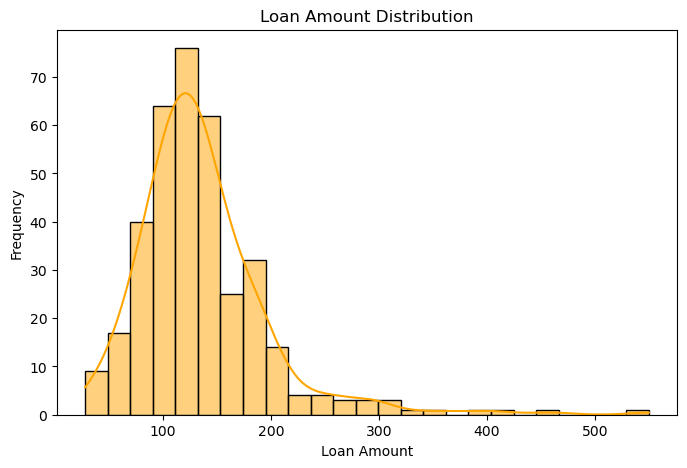

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\KALAIVANI\Downloads\Loan prediction.csv")

plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=25, kde=True, color='orange')

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

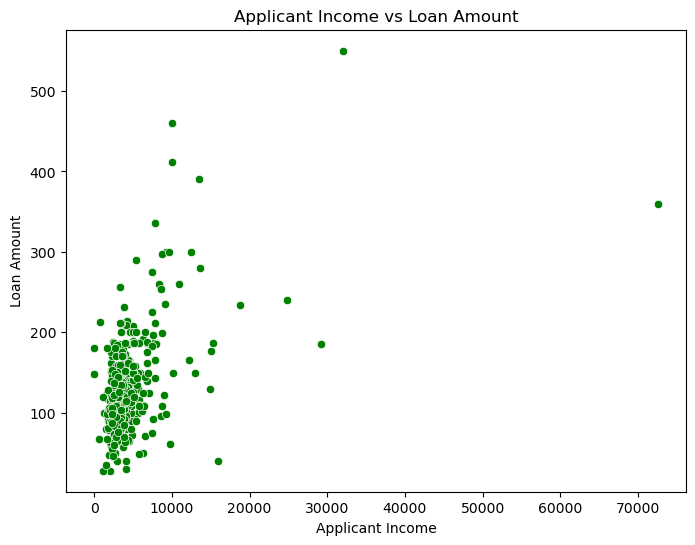

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\KALAIVANI\Downloads\Loan prediction.csv")

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', color='green')

plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")

plt.show()

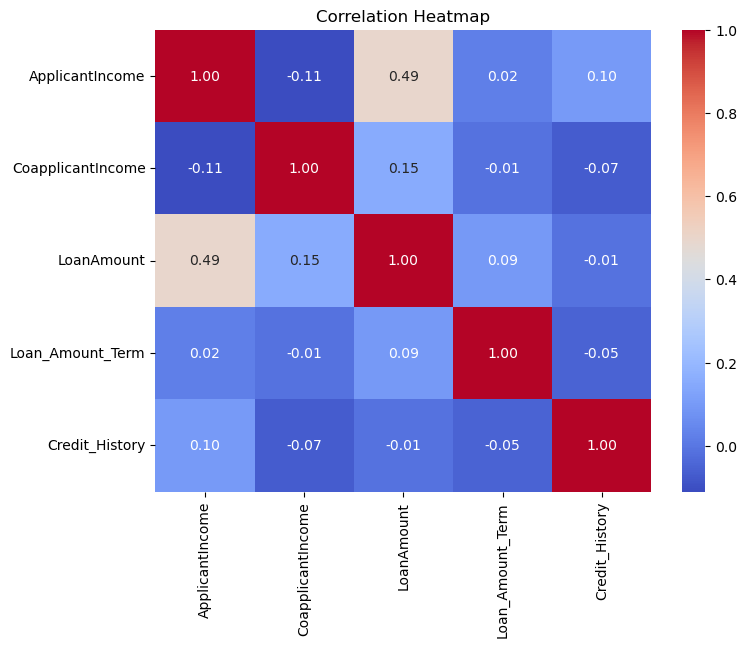

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\KALAIVANI\Downloads\Loan prediction.csv")

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()